In [10]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str,
    format_model_str_word_task,
    normalize_model_list,
    normalize_model_name,
    normalize_palette_dict,
    marker_palette_for_hue,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    get_plot_groups,
    model_label,
    plot_grouped_bars,
)

In [11]:
def get_category_accuracies(predictions,labels,target):
    """
    Returns the accuracy for target category.
    """
    correct = 0
    total = 0
    for idx in range(len(labels)):
        label = labels[idx]
        if label==target:
            prediction = predictions[idx]
            if label==prediction:
                correct = correct+1
            total = total+1
    return correct/total


# format_model_str is imported from figure_utils




## Get ESC 50 results for each model

In [12]:
path_to_esc_results = Path("esc_analysis")

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet18_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("resnet50_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
                
    if 'projects' in str(results_path):
        continue 
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))

    df_list.append(data)

esc_50_df = pd.DataFrame.from_records(df_list)
esc_50_df['test_layer'] = esc_50_df['test_layer'].astype('str')
esc_50_df['model_name'] = esc_50_df['model_name'].apply(normalize_model_name)

esc_50_df = esc_50_df.loc[esc_50_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [13]:


esc_50_df.model_name.unique()

array(['CochDNN9 supervised word', 'CochDNN9 ssl λ=0.1',
       'CochDNN9 ssl dual λ=0.0', 'CochDNN9 supervised multi-task',
       'resnet18 ssl λ=0.01', 'resnet18 ssl λ=0.3',
       'CochDNN9 ssl dual λ=0.5', 'CochDNN9 ssl λ=0.3',
       'CochDNN9 ssl λ=0.4', 'resnet18 ssl λ=0.1', 'resnet18 ssl',
       'resnet18 ssl λ=1.0', 'CochDNN9 ssl λ=0.2', 'CochDNN9 ssl λ=0.8',
       'CochDNN9 ssl λ=0.5', 'CochDNN9 ssl λ=0.0', 'resnet18 ssl λ=0.2',
       'CochDNN9 supervised audioset', 'resnet18 ssl λ=0.4',
       'resnet18 ssl λ=0.5', 'CochDNN9 ssl λ=1.0',
       'CochDNN9 scaled ssl λ=0.5', 'CochDNN9 scaled supervised',
       'CochDNN9 ssl dual λ=0.01', 'CochDNN9 scaled ssl λ=0.0',
       'CochDNN9 ssl dual λ=0.0 unpaired augs', 'CochDNN9 ssl dual λ=0.1',
       'resnet18 scaled ssl λ=0.5', 'resnet50 ssl λ=0.5',
       'resnet50 scaled ssl λ=0.5', 'resnet18 scaled ssl λ=0.0',
       'resnet18 supervised audioset', 'resnet50 supervised audioset',
       'byol-a λ=0.0', 'byol-a'], dtype=obj

## Get speech commands task results

In [31]:
path_to_speech_commands_results = Path("eval_jsin_results/linear_eval_speech_commands")
kell2018_speech_commands_results = list(path_to_speech_commands_results.rglob("*kell2018*full*cosine*.pkl"))
kell2018_speech_commands_results = [path for path in kell2018_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'mmcr']])]

resnet18_speech_commands_results = list(path_to_speech_commands_results.rglob("resnet18*.pkl"))
resnet18_speech_commands_results = [path for path in resnet18_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop']])]

byola_results =  list(path_to_speech_commands_results.rglob("config_*cosine*.pkl"))

all_speech_commands_task_results = kell2018_speech_commands_results + resnet18_speech_commands_results + byola_results

df_list = []

for i, results_path in enumerate(all_speech_commands_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if "equivariant" in path_str and not "cosine" in path_str:
        continue 


    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, _, eq_lmbda = format_model_str_word_task(results_path)
    if arch_class == 'unknown' and 'config_' in path_str:
        model_name = 'byol-a'
        arch_class = 'byol-a'
        eq_lmbda = ''
    
    # Remove audioset modifiers before normalization if we have explicit eq_lmbda
    # to prevent normalize_model_name from adding another lambda
    if eq_lmbda and 'ssl' in model_name:
        model_name = re.sub(
            r'\s+(?:jsin\s+)?audioset|\s+unbalanced\s+audioset',
            '',
            model_name,
        )
        model_name = re.sub(r'\s{2,}', ' ', model_name).strip()
    
    # Normalize the model name
    model_name = normalize_model_name(model_name)
    
    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    if model_name == 'byol-a':
        test_layer = 'final'

    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

speech_commands_df = pd.DataFrame.from_records(df_list)
speech_commands_df['test_layer'] = speech_commands_df['test_layer'].astype('str')
speech_commands_df['task'] = '20-word classification'

## Get word task results 

In [15]:
path_to_word_results = Path("eval_jsin_results")
kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
# kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet18_word_results = list(path_to_word_results.rglob("resnet18*.pkl"))
resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

resnet50_word_results = list(path_to_word_results.rglob("resnet50*.pkl"))
resnet50_word_results = [path for path in resnet50_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + resnet18_word_results + resnet50_word_results + byola_results

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
        
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

word_df = pd.DataFrame.from_records(df_list)
word_df['test_layer'] = word_df['test_layer'].astype('str')
word_df['model_name'] = word_df['model_name'].apply(normalize_model_name)
word_df['task'] = '800-word classification'

In [16]:
word_df.model_name.unique()

array(['CochDNN9 ssl λ=0.5', 'CochDNN9 ssl dual λ=0.0 unpaired augs',
       'CochDNN9 ssl dual λ=0.01', 'CochDNN9 supervised word',
       'CochDNN9 ssl λ=0.3', 'CochDNN9 ssl λ=0.1', 'CochDNN9 ssl λ=0.4',
       'CochDNN9 ssl λ=0.2', 'CochDNN9 supervised multi-task',
       'CochDNN9 scaled ssl λ=0.0', 'CochDNN9 scaled ssl λ=0.5',
       'CochDNN9 supervised audioset', 'CochDNN9 ssl λ=0.0',
       'CochDNN9 ssl dual λ=0.5', 'CochDNN9 ssl dual λ=0.1',
       'CochDNN9 scaled supervised', 'CochDNN9 ssl λ=1.0',
       'CochDNN9 ssl dual λ=0.0', 'resnet18 ssl λ=0.5',
       'resnet18 ssl λ=0.1', 'resnet18 ssl λ=0.3',
       'resnet18 scaled ssl λ=0.5', 'resnet18 scaled ssl λ=0.0',
       'resnet18 ssl', 'resnet18 ssl λ=0.4', 'resnet18 ssl λ=0.2',
       'resnet18 ssl λ=0.01', 'resnet18 ssl λ=1.0',
       'resnet50 scaled ssl λ=0.5', 'byol-a', 'byol-a λ=0.0'],
      dtype=object)

In [32]:
df = pd.concat([esc_50_df, speech_commands_df, word_df], axis=0, ignore_index=True)
df.head()

,model_name,arch_class,test_layer,eq_lmbda,overall_acc,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem,task,speaker_top1_mean,speaker_top1_sem,speaker_top5_mean,speaker_top5_sem
0,CochDNN9 supervised word,kell2018,preproc,,0.2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CochDNN9 ssl λ=0.1,kell2018,preproc,0.1,0.2480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CochDNN9 ssl dual λ=0.0,kell2018,preproc,0.0,0.2485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CochDNN9 supervised multi-task,kell2018,preproc,,0.2485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,resnet18 ssl λ=0.01,resnet18,preproc,0.01,0.2485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Plot Task results

### Make main figure plot with supervised models as reflines

In [18]:
# Get standardized hue order and colors
hue_order = get_standard_hue_order()
marker_palette = marker_palette_for_hue(hue_order)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

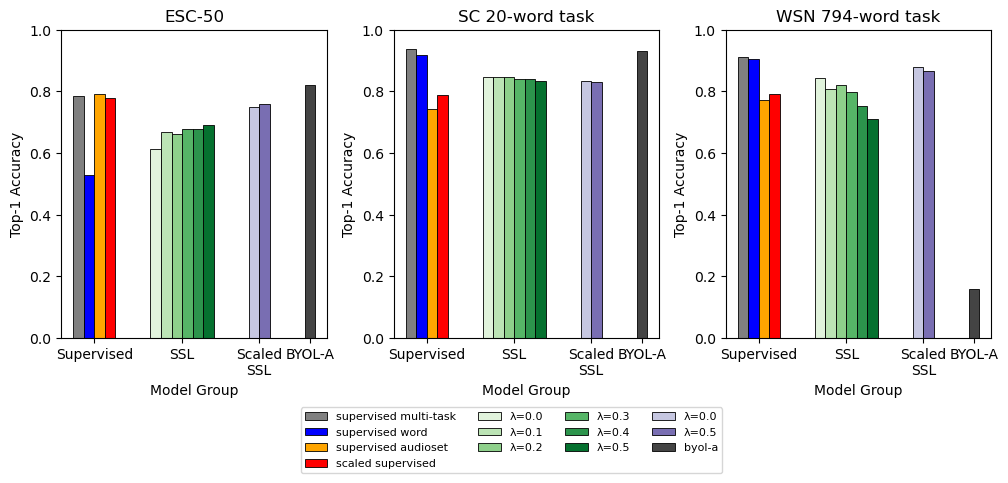

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re


# Focus on relu layers only (as before)
esc_50_to_plot = df[~df.overall_acc.isna() & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]
speech_commands_to_plot = df[~df.word_top1_mean.isna() & (df.task == '20-word classification') & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]
word_to_plot = df[~df.word_top1_mean.isna() & (df.task == '800-word classification') & ((df.test_layer.str.contains('relu4')) | ((df.model_name == 'byol-a') & (df.test_layer.str.contains('final'))))]

# Get model groups (for legend handling)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

esc_handles, esc_labels = plot_grouped_bars(
    axes[0],
    esc_50_to_plot,
    value_col='overall_acc',
    title='ESC-50',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

speech_commands_handles, speech_commands_labels = plot_grouped_bars(
    axes[1],
    speech_commands_to_plot,
    value_col='word_top1_mean',
    title='SC 20-word task',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)

word_handles, word_labels = plot_grouped_bars(
    axes[2],
    word_to_plot,
    value_col='word_top1_mean',
    title='WSN 794-word task',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)
axes[0].set_ylim(0, 1.0)
axes[1].set_ylim(0, 1.0)
axes[2].set_ylim(0, 1.0)

# Build a single legend shared across all panels
legend_handles = []
legend_labels = []
for handles, labels in [(esc_handles, esc_labels)]:
    for handle, label in zip(handles, labels):
        # if label not in legend_labels:
        legend_handles.append(handle)
        legend_labels.append(label)

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
    )

# ax.grid(axis='y', alpha=0.3, zorder=-1)
plt.subplots_adjust(wspace=0.25)
# plt.tight_layout()
# plt.show()